# Assignment #3 - Embeddings

<font color="red"> <b> Due: Apr 3rd (Friday) </b> </font>

<font color="blue"> Abeoseh Flemister </font>

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
from tensorflow.keras.datasets import imdb # IMDB dataset is included in Keras

from keras.models import Sequential  # Model type to be used
from keras.layers import Dense, Dropout, Activation # Types of layers to be used in our model
from keras.layers import Embedding, LSTM
from tensorflow.keras.utils import to_categorical          # Converts a class vector (integers) to binary class matrix.
from tensorflow.keras import regularizers

print("TF version:", tf.__version__)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

TF version: 2.20.0


# Introduction
The goal of this assignment is to practice learning how embeddings and RNN work for NLP tasks and how to leverage the pretrained embeddings.

[General introduction of this writing assignment] Describe the objective of this assignment. You can briefly state how you accompilsh it.

# Data

Let us reuse **IMDB dataset** that we used last week. But this time, let us use the one in the Keras datasets.

[Refer to this link for better understanding](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/load_data)


In [3]:
max_features = 20000

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

# Method

## Word Embeddings

Crucially, when you encode something via one-hot encoding, you’re making a feature- engineering decision. You’re injecting into your model a fundamental assumption about the structure of your feature space. That assumption is that the different tokens you’re encoding are all independent from each other: indeed, one-hot vectors are all orthogonal to one another. And in the case of words, that assumption is clearly wrong. Words form a structured space: they share information with each other. The words “movie” and “film” are interchangeable in most sentences, so the vector that represents “movie” should not be orthogonal to the vector that represents “film”—they should be
the same vector, or close enough.

To get a bit more abstract, the geometric relationship between two word vectors
should reflect the semantic relationship between these words. For instance, in a reasonable word vector space, you would expect synonyms to be embedded into similar word vectors, and in general, you would expect the geometric distance (such as the cosine distance or L2 distance) between any two word vectors to relate to the “semantic distance” between the associated words. Words that mean different things should lie far away from each other, whereas related words should be closer.

Word embeddings are vector representations of words that achieve exactly this: they map human language into a structured geometric space. Whereas the vectors obtained through one-hot encoding are binary, sparse (mostly made of zeros), and very high-dimensional (the same dimensionality as the numb words in the vocabulary), word embeddings are low-dimensional floating-point vectors
(that is, dense vectors, as opposed to sparse vectors); see figure 11.2. It’s common to see word embeddings that are 256-dimensional, 512-dimensional, or 1,024-dimensional when dealing with very large vocabularies. On the other hand, one-hot encoding words generally leads to vectors that are 20,000-dimensional or greater (capturing a vocabulary of 20,000 tokens, in this case). So, word embeddings pack more information into far fewer dimensions.

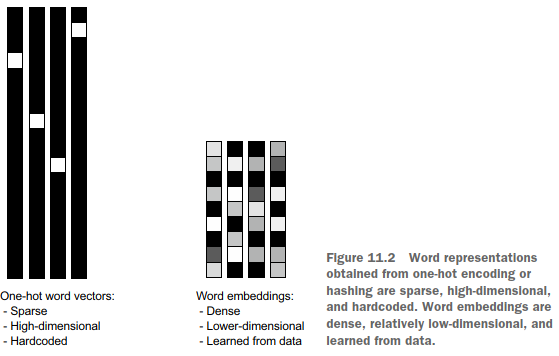



## Using pretrained Word Embeddings

In this assignment, we will use GloVe word embeddings which is precomputed on the 2014
English Wikipedia dataset. It’s an 822 MB zip file containing 100-dimensional embedding vectors for 400,000 words (or non-word tokens). You can download the word embedding file which contains embeddings for each word as the image below. After downloading the image, you can open and see the raw file before using it.

![](https://i1.wp.com/turbolab.in/wp-content/uploads/2021/12/glove.jpg?resize=500%2C358&ssl=1)

First I am extracting the pretrained embeddings `'glove.6B.100d.txt'`.

In [10]:
# Download the dataset
import urllib.request
import zipfile

url = "http://nlp.stanford.edu/data/glove.6B.zip"
filename = "glove.6B.zip"

urllib.request.urlretrieve(url, filename)

with zipfile.ZipFile(filename, 'r') as zip_ref:
    zip_ref.extract('glove.6B.100d.txt')

Then I am reading them into a dictionary.

In [11]:
path_to_glove_file = 'glove.6B.100d.txt'
embeddings_index = {}

i = 0
with open(path_to_glove_file, "+r") as file:
    for line in file:
        word = line.split(" ")[0]
        vector = " ".join(line.split(" ")[1:])
        embeddings_index[word] = np.fromstring(vector, sep=' ')

print(f"Fount {len(embeddings_index)} word vectors.")

Fount 400000 word vectors.


Visualizing two of the embeddings. 

In [ ]:
import itertools as it

dict(it.islice(embeddings_index.items(), 2))

## Model

Once you complete preprocessing of your iMDB dataset with the GloVe embeddings, build your own RNN (other than LSTM) to classify the review sentiment.

In [ ]:
## GRU? etc.

# Experiments

Train and test your model and report your observations.

# Conclusions

Discuss the challenges or somethat that you learned.
If you have any suggestion about the assignment, you can write about it.

# References

List your references to complete your assignment. Use a proper reference style (APA, MLA, etc.).

# Grading

Your notebook is supposed to run well after downloading data to the working directory.

**Note: this is a WRITING assignment. Proper writing is REQUIRED. Comments are not considered as writing.**


Points | | Description
--|--|:--
5 | Introduction  
10 | Data Analysis |
20 | Word Embeddings |
20 | Pretrained Word Embeddings |
35 | RNN Model |
5 | Conclusions
5 | References